In [12]:
# Auto-Reload for Fast Iteration
%load_ext autoreload
%autoreload 2

# --- Add project root (the dir that contains 'utils/') to sys.path ---
from pathlib import Path
import sys

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "utils").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT)) # insert project root at the front of the search list
print("Project root:", ROOT)  # sanity check

# Import custom functions from utils package
from utils.models import VAE, CVAE
from utils.train_utils import (
    train_vae,
    loss_function,
    get_latent_mu,
    get_latent_mu_cvae,
    compute_condition_distances,
    compute_per_session_dist_to_null
)
from utils.data_utils import (
    load_all_fc_data,
    preprocess_for_torch
)
from utils.utils_plotting import (
    plot_vae_losses,
    plot_latent_embedding_by_condition_and_subject,
    plot_subject_distance_comparison
)
from utils.bootstrap import *   # common imports, DEVICE

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: /Users/liuq13/project-nodeap-fmri-cvae


In [13]:
DATA_DIR = (ROOT / "data").resolve()
sub_cond_path     = DATA_DIR / "SubConds.xlsx"
base_nifti_folder = DATA_DIR / "data_FC"
condition_map = {'N': 0, 'S': 1, 'C': 2}

In [14]:
# Load and preprocess
use_roi = 0
all_corr_data, all_tms_type, all_subject_id, all_stimloc, all_session = load_all_fc_data(sub_cond_path, 
                                                               base_nifti_folder, 
                                                               mat_filename='conn_matrix_w_sphere.mat',
                                                               key_name='correlation_matrix',row_idx=use_roi)
# One-hot encode subject ID as condition
subject_arr = np.array(all_subject_id).reshape(-1, 1)
subject_encoder = OneHotEncoder(sparse_output=False, drop=None)
subject_ohe = subject_encoder.fit_transform(subject_arr)  # shape: [n_samples, n_subjects]

# Convert to torch tensors
X_tensor = preprocess_for_torch(all_corr_data)  
subject_cond_tensor = torch.tensor(subject_ohe, dtype=torch.float32)
dataset = TensorDataset(X_tensor, subject_cond_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

[WARN] File not found: /Users/liuq13/project-nodeap-fmri-cvae/data/data_FC/NODEAP_30/S3D2/conn_matrix_w_sphere.mat
[WARN] File not found: /Users/liuq13/project-nodeap-fmri-cvae/data/data_FC/NODEAP_44/S1D1/conn_matrix_w_sphere.mat
[WARN] File not found: /Users/liuq13/project-nodeap-fmri-cvae/data/data_FC/NODEAP_83/S3D1/conn_matrix_w_sphere.mat
[WARN] File not found: /Users/liuq13/project-nodeap-fmri-cvae/data/data_FC/NODEAP_87/D0/conn_matrix_w_sphere.mat
[WARN] File not found: /Users/liuq13/project-nodeap-fmri-cvae/data/data_FC/NODEAP_88/D0/conn_matrix_w_sphere.mat
Columns with NaN: 14 / 116
Tensor shape after preprocessing: torch.Size([331, 102])


In [15]:
X_tensor.shape

torch.Size([331, 102])

In [16]:
subject_cond_tensor.shape

torch.Size([331, 48])

In [17]:
all_tms_type

array(['N', 'S', 'S', 'S', 'C', 'C', 'S', 'N', 'S', 'S', 'C', 'S', 'S',
       'C', 'N', 'C', 'S', 'S', 'S', 'S', 'C', 'N', 'S', 'S', 'S', 'C',
       'C', 'S', 'N', 'S', 'S', 'S', 'C', 'C', 'S', 'N', 'C', 'S', 'S',
       'C', 'S', 'S', 'N', 'S', 'C', 'S', 'S', 'C', 'S', 'N', 'S', 'C',
       'S', 'S', 'C', 'S', 'N', 'S', 'C', 'S', 'S', 'C', 'S', 'N', 'S',
       'C', 'C', 'S', 'S', 'S', 'N', 'S', 'S', 'S', 'C', 'C', 'S', 'N',
       'S', 'C', 'C', 'S', 'S', 'S', 'N', 'S', 'C', 'C', 'S', 'S', 'N',
       'C', 'S', 'S', 'S', 'S', 'C', 'N', 'C', 'S', 'S', 'C', 'S', 'S',
       'N', 'C', 'S', 'S', 'C', 'S', 'S', 'N', 'S', 'S', 'S', 'C', 'C',
       'S', 'N', 'S', 'C', 'C', 'S', 'S', 'S', 'N', 'C', 'S', 'S', 'C',
       'S', 'S', 'N', 'S', 'S', 'S', 'S', 'C', 'N', 'S', 'S', 'C', 'S',
       'S', 'C', 'N', 'S', 'C', 'C', 'S', 'S', 'S', 'N', 'C', 'S', 'S',
       'C', 'S', 'S', 'N', 'S', 'S', 'S', 'C', 'C', 'S', 'N', 'S', 'C',
       'S', 'S', 'C', 'S', 'N', 'S', 'S', 'C', 'S', 'S', 'C', 'N

In [18]:
# Set up model, optimizer, and device
input_dim = X_tensor.shape[1]
cond_dim = subject_cond_tensor.shape[1]
latent_dim = 10
hidden_dim = 64 
NUM_EPOCH = 500
LR = 3e-4
model = CVAE(input_dim=input_dim, cond_dim=cond_dim, latent_dim=latent_dim, hidden_dim=hidden_dim).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
total_loss_hist, recon_loss_hist, kld_loss_hist = train_vae(model, dataloader, optimizer, device=DEVICE, epochs=NUM_EPOCH)


===== Epoch 1 =====


Epoch 1/500: 100%|███████████████████████████████████████████████| 11/11 [00:00<00:00, 1174.61it/s]


Epoch 1, Loss: 104.0440, Recon: 103.7289, KL: 0.3151

===== Epoch 2 =====


Epoch 2/500: 100%|███████████████████████████████████████████████| 11/11 [00:00<00:00, 1137.76it/s]


Epoch 2, Loss: 103.3591, Recon: 103.0972, KL: 0.2619

===== Epoch 3 =====


...

Epoch 498, Loss: 27.5590, Recon: 18.5552, KL: 9.0039

===== Epoch 499 =====


Epoch 499/500: 100%|█████████████████████████████████████████████| 11/11 [00:00<00:00, 1286.09it/s]


Epoch 499, Loss: 27.4313, Recon: 18.4686, KL: 8.9627

===== Epoch 500 =====


Epoch 500/500: 100%|█████████████████████████████████████████████| 11/11 [00:00<00:00, 1292.29it/s]

Epoch 500, Loss: 27.5465, Recon: 18.5915, KL: 8.9550


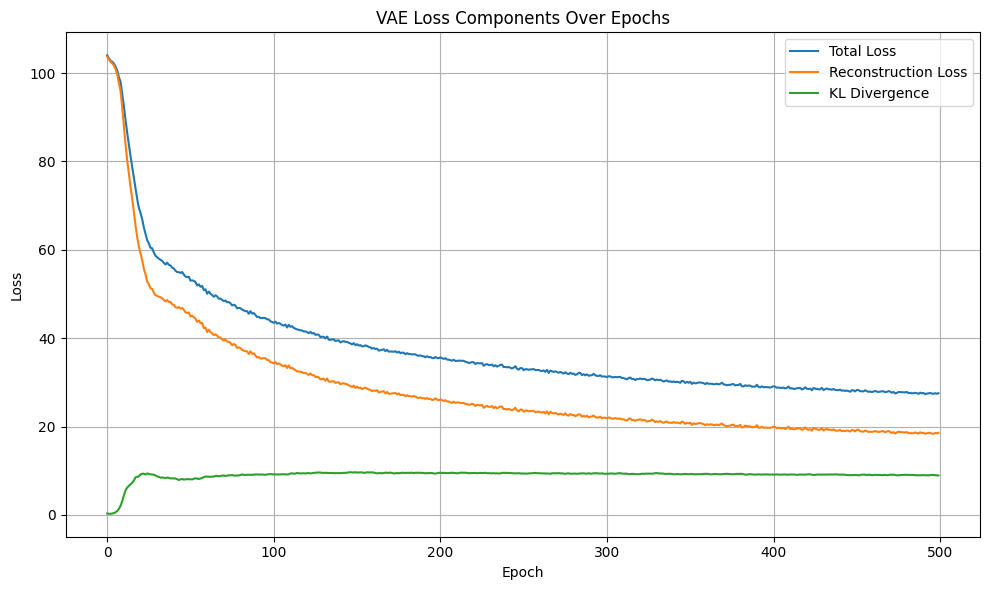

In [19]:
plot_vae_losses(total_loss_hist, recon_loss_hist, kld_loss_hist)

dim of latent mu: (331, 10)


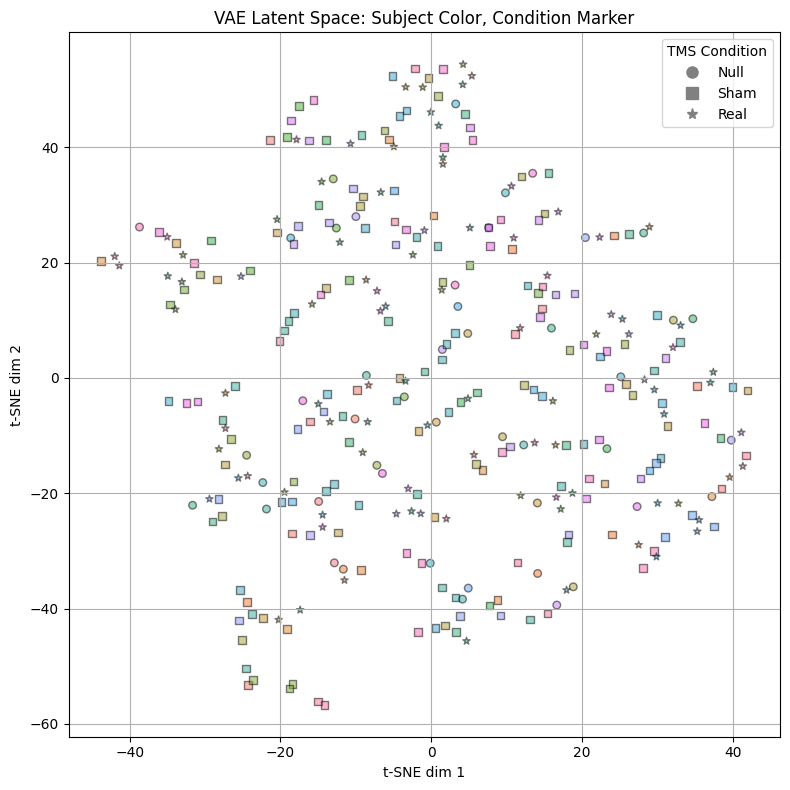

In [20]:
mu_all = get_latent_mu_cvae(model, X_tensor, subject_cond_tensor, device=DEVICE)
# 2d-TSNE
z_2d = TSNE(n_components=2, perplexity=8).fit_transform(mu_all)
plot_latent_embedding_by_condition_and_subject(z_2d, all_tms_type, all_subject_id)

Paired t-test: t = -2.259, p = 0.0288


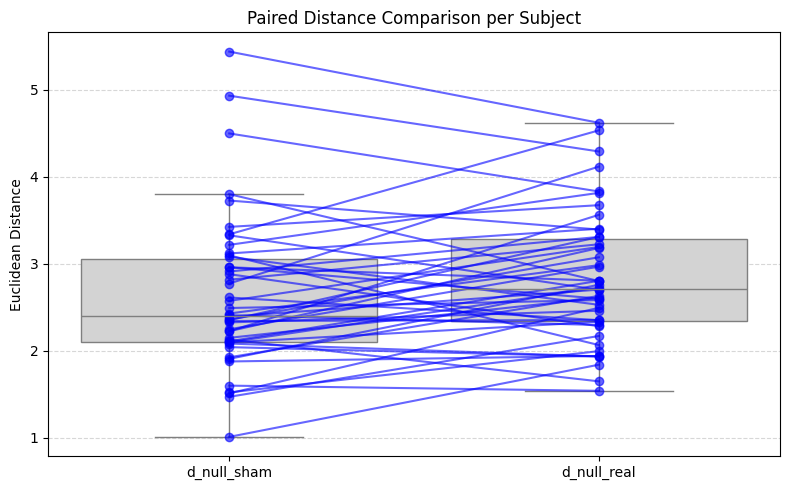

In [21]:
df = compute_condition_distances(mu_all, all_tms_type, all_subject_id, condition_map)

# Paired t-test
t_stat, p_val_t = ttest_rel(df["d_null_sham"], df["d_null_real"])
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_val_t:.4f}")
plot_subject_distance_comparison(df)

In [23]:
output_dir = ROOT / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)   
output_filename = output_dir / f"dist_summary_roi_{use_roi}.csv"
df.to_csv(output_filename, index=False)

df_session_dists = compute_per_session_dist_to_null(mu_all, all_subject_id, all_tms_type, all_session)
output_filename = output_dir / f"session_distances_roi_{use_roi}.csv"
df_session_dists.to_csv(output_filename, index=False)